In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("mobile_sales_data.csv")

# Display basic info
print(df.info())

# Show a preview
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-null  object
 6   Dispatch Date            50000 non-null  object
 7   Quantity Sold            50000 non-null  int64 
 8   Customer Name            50000 non-null  object
 9   Customer Location        50000 non-null  object
 10  Region                   50000 non-null  object
 11  Core Specification       25017 non-null  object
 12  Processor Specification  50000 non-null  object
 13  RAM                      50000 non-null  object
 14  ROM                      50000 non-nul

In [4]:
print(df.isnull().sum())  # Identify missing values
df.dropna(inplace=True)    # Remove rows with missing data


Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64


In [5]:
# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")
print(df.columns)


Index(['product', 'brand', 'product_code', 'product_specification', 'price',
       'inward_date', 'dispatch_date', 'quantity_sold', 'customer_name',
       'customer_location', 'region', 'core_specification',
       'processor_specification', 'ram', 'rom', 'ssd'],
      dtype='object')


In [6]:
# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Fill missing categorical values with the mode
df.fillna(df.mode().iloc[0], inplace=True)

print(df.isnull().sum())  # Verify missing values handled


product                    0
brand                      0
product_code               0
product_specification      0
price                      0
inward_date                0
dispatch_date              0
quantity_sold              0
customer_name              0
customer_location          0
region                     0
core_specification         0
processor_specification    0
ram                        0
rom                        0
ssd                        0
dtype: int64


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['price', 'quantity_sold']] = scaler.fit_transform(df[['price', 'quantity_sold']])

print(df[['price', 'quantity_sold']].head())  # Check normalized values
print(df.columns)  # Lists all column names


      price  quantity_sold
1  0.203090       0.000000
3  0.081530       0.000000
4  0.332429       0.333333
5  0.951160       0.000000
7  0.051425       0.000000
Index(['product', 'brand', 'product_code', 'product_specification', 'price',
       'inward_date', 'dispatch_date', 'quantity_sold', 'customer_name',
       'customer_location', 'region', 'core_specification',
       'processor_specification', 'ram', 'rom', 'ssd'],
      dtype='object')


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['brand'] = encoder.fit_transform(df['brand'])
df['processor_specification'] = encoder.fit_transform(df['processor_specification'])

print(df[['brand', 'processor_specification']].head())  # Encoded values preview


   brand  processor_specification
1     12                        1
3     16                        6
4      8                        6
5      5                        6
7      1                        6


In [13]:
features = ['brand', 'processor_specification', 'ram', 'rom', 'price']
target = 'quantity_sold'  # Corrected column name

X = df[features]
y = df[target]

print(X.head(), y.head())  # Verify dataset structure


   brand  processor_specification   ram    rom     price
1     12                        1   8GB  512GB  0.203090
3     16                        6  12GB   64GB  0.081530
4      8                        6   8GB  128GB  0.332429
5      5                        6  16GB   64GB  0.951160
7      1                        6  12GB  128GB  0.051425 1    0.000000
3    0.000000
4    0.333333
5    0.000000
7    0.000000
Name: quantity_sold, dtype: float64


In [16]:
# Convert to datetime format
df['inward_date'] = pd.to_datetime(df['inward_date'], errors='coerce')

# Now extract the month
df['month'] = df['inward_date'].dt.month

# Verify changes
print(df[['inward_date', 'month']].head()) 


  inward_date  month
1  2023-10-03     10
3  2024-02-06      2
4  2023-08-10      8
5  2025-03-19      3
7  2023-10-29     10


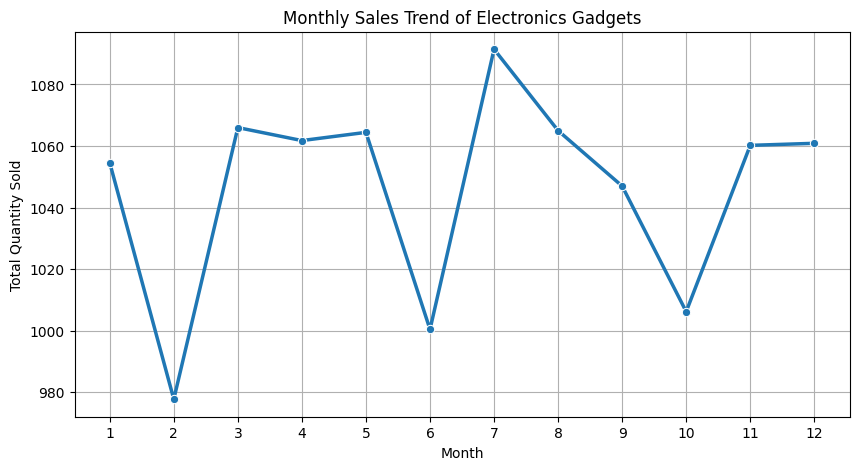

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate total quantity sold per month
monthly_sales = df.groupby('month')['quantity_sold'].sum()

# Plot the monthly sales trend
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', linewidth=2.5)
plt.xlabel('Month')
plt.ylabel('Total Quantity Sold')
plt.title('Monthly Sales Trend of Electronics Gadgets')
plt.xticks(range(1, 13))  # Ensure all months (1-12) are displayed
plt.grid()
plt.show()


C:\Users\priks\AppData\Local\Temp\ipykernel_37604\648428137.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_sales.index, y=brand_sales.values, palette='coolwarm')


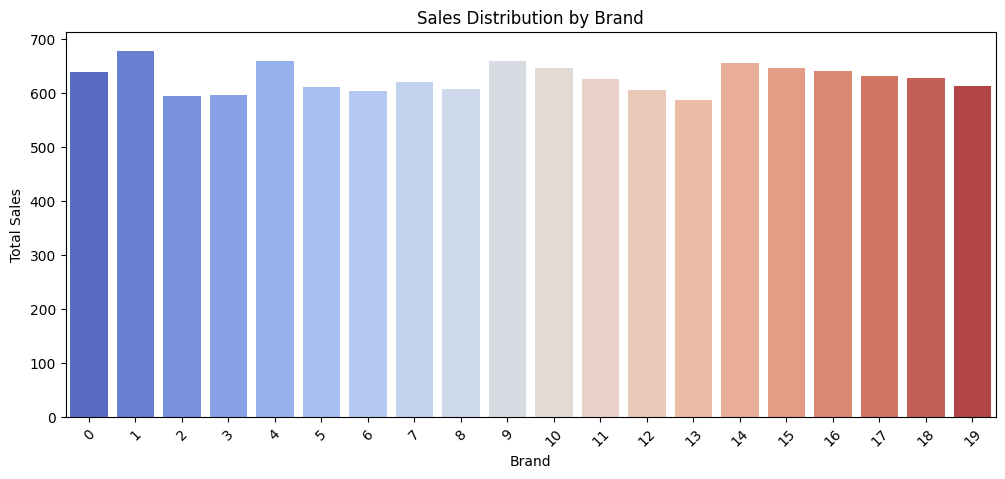

In [18]:
# Aggregate sales per brand
brand_sales = df.groupby('brand')['quantity_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=brand_sales.index, y=brand_sales.values, palette='coolwarm')
plt.xlabel('Brand')
plt.ylabel('Total Sales')
plt.title('Sales Distribution by Brand')
plt.xticks(rotation=45)
plt.show()


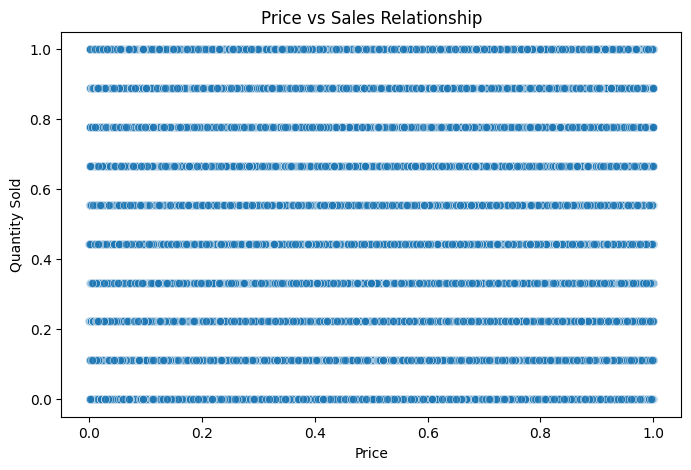

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['price'], y=df['quantity_sold'], alpha=0.7)
plt.xlabel('Price')
plt.ylabel('Quantity Sold')
plt.title('Price vs Sales Relationship')
plt.show()


In [27]:
def convert_rom(value):
    value = str(value)  # Ensure it's a string
    value = value.replace('TB', '000GB')  # Convert TB to GB
    value = value.replace('GB', '')  # Remove 'GB'
    return float(value) if value.isnumeric() else None  # Convert to float safely

df['rom'] = df['rom'].apply(convert_rom)


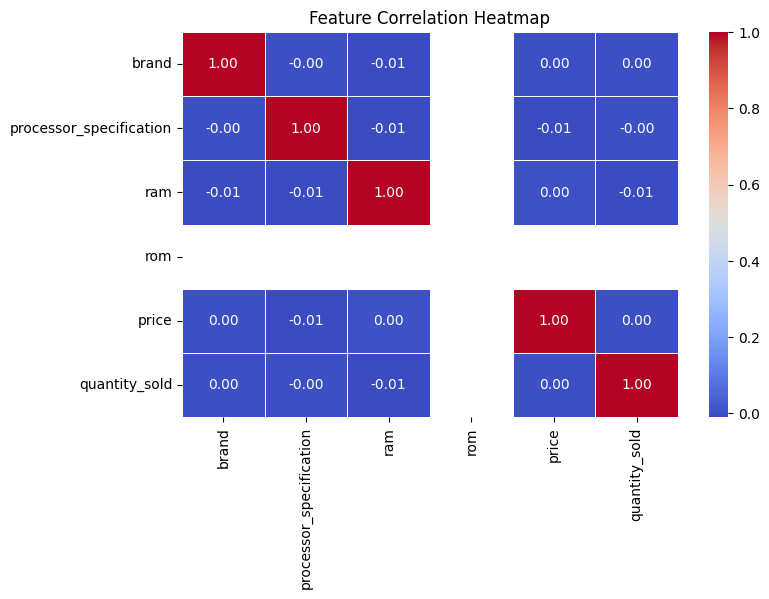

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation analysis
corr_features = ['brand', 'processor_specification', 'ram', 'rom', 'price', 'quantity_sold']

# Compute correlation matrix
corr_matrix = df[corr_features].corr()

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


### starting building LSTM

In [31]:
df = df.sort_values(by='inward_date')


In [32]:
features = ['brand', 'processor_specification', 'ram', 'rom', 'price']
target = 'quantity_sold'

X = df[features].values
y = df[target].values


In [33]:
import numpy as np

# Reshaping for LSTM format (samples, time steps, features)
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

print("Shape of X:", X.shape)  # Verify structure
print("Shape of y:", y.shape)


Shape of X: (25017, 1, 5)
Shape of y: (25017,)


In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [35]:
# Initialize the model
model = Sequential()

# First LSTM layer with dropout to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Fully connected output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


c:\Users\priks\anaconda3\envs\health\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
import numpy as np
import pandas as pd

# Ensure all features are numeric
df[features] = df[features].apply(pd.to_numeric, errors='coerce')

# Ensure target variable is numeric
df[target] = pd.to_numeric(df[target], errors='coerce')

# Drop NaN values that may arise from conversion
df.dropna(inplace=True)

# Convert to NumPy arrays
X = df[features].values
y = df[target].values

# Reshape for LSTM model
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

print("Updated Shape of X:", X.shape)
print("Updated Shape of y:", y.shape)
print(df.dtypes)  # Verify column types
print(df.head())  # Ensure numeric data


Updated Shape of X: (0, 1, 5)
Updated Shape of y: (0,)
product                            object
brand                               int64
product_code                       object
product_specification              object
price                             float64
inward_date                datetime64[ns]
dispatch_date                      object
quantity_sold                     float64
customer_name                      object
customer_location                  object
region                             object
core_specification                 object
processor_specification             int64
ram                               float64
rom                               float64
ssd                                object
month                               int32
dtype: object
Empty DataFrame
Columns: [product, brand, product_code, product_specification, price, inward_date, dispatch_date, quantity_sold, customer_name, customer_location, region, core_specification, processor_specification, r

In [45]:
print(df.isnull().sum())  # Check missing values count per column
print(df.shape)  # Check total number of rows and columns
# Fill missing numeric values with median
df[features] = df[features].apply(pd.to_numeric, errors='coerce')  # Convert to numeric
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill NaNs with median

# Fill missing categorical values with 'Unknown'
df.fillna('Unknown', inplace=True)
X = df[features].values
y = df[target].values

X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

print("Fixed Shape of X:", X.shape)  # Should not be (0, 1, 5) anymore
print("Fixed Shape of y:", y.shape)  # Should have meaningful values


product                    0
brand                      0
product_code               0
product_specification      0
price                      0
inward_date                0
dispatch_date              0
quantity_sold              0
customer_name              0
customer_location          0
region                     0
core_specification         0
processor_specification    0
ram                        0
rom                        0
ssd                        0
month                      0
dtype: int64
(0, 17)
Fixed Shape of X: (0, 1, 5)
Fixed Shape of y: (0,)


In [46]:
import pandas as pd

# Reload original dataset
df = pd.read_csv("mobile_sales_data.csv")

# Display basic information
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-null  object
 6   Dispatch Date            50000 non-null  object
 7   Quantity Sold            50000 non-null  int64 
 8   Customer Name            50000 non-null  object
 9   Customer Location        50000 non-null  object
 10  Region                   50000 non-null  object
 11  Core Specification       25017 non-null  object
 12  Processor Specification  50000 non-null  object
 13  RAM                      50000 non-null  object
 14  ROM                      50000 non-nul

In [47]:
print(df.isnull().sum())  # Check missing values
print(df.shape)  # Confirm dataset size


Product                        0
Brand                          0
Product Code                   0
Product Specification          0
Price                          0
Inward Date                    0
Dispatch Date                  0
Quantity Sold                  0
Customer Name                  0
Customer Location              0
Region                         0
Core Specification         24983
Processor Specification        0
RAM                            0
ROM                            0
SSD                        24983
dtype: int64
(50000, 16)


In [51]:
print(df.columns)  # Lists all existing columns
print(df.head())  # Preview the dataset
df = pd.read_csv("mobile_sales_data.csv")  # Reload original dataset



Index(['Product', 'Brand', 'Product Code', 'Product Specification', 'Price',
       'Inward Date', 'Dispatch Date', 'Quantity Sold', 'Customer Name',
       'Customer Location', 'Region', 'Core Specification',
       'Processor Specification', 'RAM', 'ROM', 'SSD'],
      dtype='object')
        Product      Brand Product Code  \
0  Mobile Phone   Motorola     88EB4558   
1        Laptop       Oppo     416DFEEB   
2  Mobile Phone    Samsung     9F975B08   
3        Laptop       Sony     73D2A7CC   
4        Laptop  Microsoft     CCE0B80D   

                               Product Specification   Price Inward Date  \
0  Site candidate activity company there bit insi...   78570  2023-08-02   
1            Beat put care fight affect address his.   44613  2023-10-03   
2           Energy special low seven place audience.  159826  2025-03-19   
3  Friend record hard contain minute we role sea ...   20911  2024-02-06   
4   Program recently feeling save tree hotel people.   69832  2023-08-10 

In [52]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Quantity Sold'] = pd.to_numeric(df['Quantity Sold'], errors='coerce')
df['RAM'] = df['RAM'].str.replace('GB', '').astype(float)
df['ROM'] = df['ROM'].apply(lambda x: str(x).replace('TB', '000GB').replace('GB', '')).astype(float)

# Fill missing values to prevent dropping rows
df.fillna(df.median(numeric_only=True), inplace=True)
df.fillna('Unknown', inplace=True)

print(df.shape)  # Confirm the dataset is preserved


(50000, 16)


In [53]:
import numpy as np
from sklearn.model_selection import train_test_split

# Select relevant features
features = ['Brand', 'Processor Specification', 'RAM', 'ROM', 'Price']
target = 'Quantity Sold'

X = df[features].values
y = df[target].values


In [54]:
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))  # Reshape for LSTM input

print("Final Shape of X:", X.shape)  # Should be (50000, 1, 5)
print("Final Shape of y:", y.shape)


Final Shape of X: (50000, 1, 5)
Final Shape of y: (50000,)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [61]:
from sklearn.preprocessing import OneHotEncoder

# Apply One-Hot Encoding to categorical columns
df = pd.get_dummies(df, columns=categorical_features)
